<a href="https://colab.research.google.com/github/Alokathilakarathna/ME422_B3/blob/main/RIgid%20Body%20Control/e20443.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RIgid Body Control Lab

## Instructions

* Complete the activities in groups
that were assigned for ME421 for the vibrations lab.

* Make a copy of this and save it in your group github group repository with your index number as the file name

* Do all your work, EXCLUSIVELY, in that saved notebook. Your github commits will serve as a refelection of your individual contributions.

## References

* https://github.com/mugalan/intrinsic-rigid-body-control-estimation/tree/main/rigid-body-control

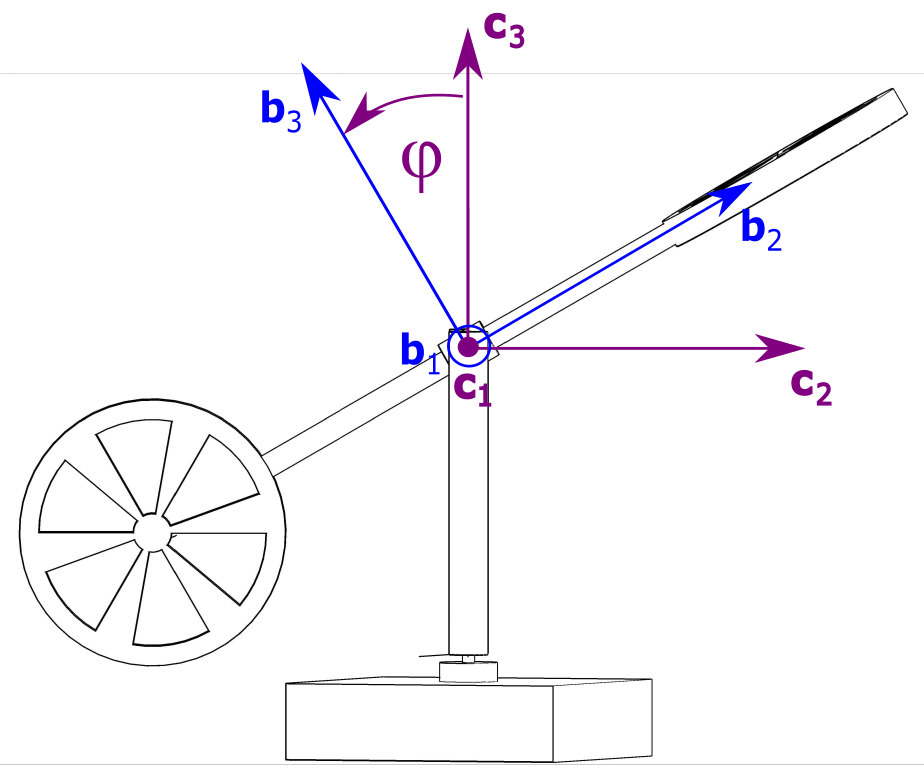

# Task 1: Twin Rotor System Dynamic Model

Show that the twin rotor system shown above can be modelled by

\begin{align}
\dot{R}&=\widehat{\omega}R,\\
\dot{\pi}&=\tau^e+\tau^u,
\end{align}
where
\begin{align}
\omega &=(\mathbb{I}^R)^{-1}\pi,
\end{align}
Here we have split the force and control moments into unmanipulatable and manipulatable (control) part. The manipulatable (control) part will be denoted by a superscript $u$ and takes the form

\begin{align*}
\tau^u &=R\begin{bmatrix}
1 & 0\\
0 & 0\\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos{\alpha} & -\cos{\beta}\\
\sin{\alpha} & -\sin{\beta}
\end{bmatrix}
\begin{bmatrix}
u_1\\ u_2
\end{bmatrix}
\end{align*}
and the constriant moment that prevents the rotation of the device about $\mathbb{b}_2$ axis is
\begin{align}
\tau^e=R\begin{bmatrix}0\\T_2\\0
\end{bmatrix}
\end{align}
with $T_2$ given by
\begin{align}
T_2&=e_2^T \left(\Omega \times \mathbb{I}\Omega+\mathbb{I}\dot{\Omega}
\right)
\end{align}
where $\Omega = R^T\omega$.

# Task 1 Answer: Twin Rotor System Dynamic Model

### 1. Coordinate Frames and Rotation Matrices

We define three coordinate frames to model the system:
* **Inertial Frame ($e$):** Fixed to the ground.
* **Intermediate Frame ($c$):** Rotates about the vertical axis ($e_3$) by angle $\theta$.
* **Body Frame ($b$):** Rotates about the horizontal axis ($c_1$) by angle $\phi$.

The elementary rotation matrices are defined as:

$$
R_3(\theta) = \begin{bmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta & \cos\theta & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

$$
R_1(\phi) = \begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\phi & -\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}
$$

The total rotation matrix $R$ describing the orientation of the body frame relative to the inertial frame is given by the product:

$$
R = R_1(\phi) R_3(\theta)
$$

---

### 2. Kinematics (Angular Velocity)

The body angular velocity vector $\Omega$ is derived from the time derivatives of the generalized coordinates ($\dot{\phi}, \dot{\theta}$):

$$
\Omega = \dot{\phi} R_3^T(\theta) e_1 + \dot{\theta} e_3
$$

Where standard basis vectors are $e_1 = [1, 0, 0]^T$ and $e_3 = [0, 0, 1]^T$.

The kinematic relationship for the rotation matrix is:

$$
\dot{R} = R \hat{\Omega}
$$

---

### 3. Dynamics (Equations of Motion)

The system dynamics are governed by the conservation of angular momentum. We define the **Spatial Angular Momentum** $\pi$ as:

$$
\pi = R \mathbb{I} \Omega
$$

Where $\mathbb{I} = \text{diag}(I_1, I_2, I_3)$ is the inertia tensor in the body frame. The equations of motion in the inertial frame are given by:

$$
\dot{\pi} = \tau^e + \tau^u
$$

Where:
* $\tau^u$: Control torques (manipulatable inputs).
* $\tau^e$: External/Constraint torques (unmanipulatable).

---

### 4. Control Torques ($\tau^u$)

The control torque is generated by the thrusts $u_1$ and $u_2$ from the two rotors. The force vectors are tilted by angles $\alpha$ and $\beta$. The control torque in the spatial frame is expressed as:

$$
\tau^u = R
\begin{bmatrix}
1 & 0 \\
0 & 0 \\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos\alpha & -\cos\beta \\
\sin\alpha & -\sin\beta
\end{bmatrix}
\begin{bmatrix}
u_1 \\
u_2
\end{bmatrix}
$$

This structure confirms that control inputs only generate moments about the $b_1$ and $b_3$ axes, leaving the $b_2$ axis unactuated.

---

### 5. Constraint Moment ($T_2$)

Since the twin rotor arm is mechanically constrained and cannot rotate about its own axis ($b_2$), a constraint moment $T_2$ is generated by the pivot to enforce this condition.

The external torque vector is:

$$
\tau^e = R \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix}
$$

To find the magnitude of $T_2$, we project the body-frame dynamics onto the constrained axis $e_2$. The constraint moment is given by:

$$
T_2 = e_2^T (\Omega \times \mathbb{I}\Omega + \mathbb{I}\dot{\Omega})
$$

# Task2
Simulate and animate the motion of the system for various different realistic inputs. For examle a vertical axis spin and a horizontal axis swing up and down motion

In [1]:
# --- STEP 1: INSTALLATION ---
# Installing the specific simulation library used in the course
!pip install --quiet "git+https://github.com/mugalan/classical-mechanics-from-a-geometric-point-of-view.git#egg=rigid-body-sim"

# --- STEP 2: IMPORTS ---
import numpy as np
import scipy as sp
from scipy.integrate import odeint
import math
from numpy import linalg
# Try/Except block handles the module import name
try:
    from rigid_body_sim import sims
except ImportError:
    import sims

# Initialize the simulation object
mr = sims.RigidBodySim()

# --- STEP 3: EXTERNAL FORCE MODEL (GRAVITY) ---
# Adapted from PDF Page 4 [Source: 2243]
def externalForceModel(qq, parameters, X):
    R = X[0][0] # Current Rotation Matrix
    M = parameters['M']
    g = parameters['g']
    CM = parameters['CM']

    # PDF defines fe and taue. We calculate gravity moment for realistic motion.
    # Gravity Force Vector in Spatial Frame: [0, 0, -Mg]
    F_gravity = np.array([0, 0, -M*g])

    # Gravity Moment = (R * CM) x F_gravity
    # qq.hat_matrix computes the cross product matrix
    taue = qq.hat_matrix(R @ CM) @ F_gravity

    fe = np.array([0, 0, 0])
    return [taue, fe]

# --- STEP 4: ACTUATOR MODEL ---
# Adapted from PDF Page 4 [Source: 2249]
def actuator(qq, parameters, t, X, taue, fe):
    R = X[0][0]
    alpha = parameters['alpha']
    beta = parameters['beta']
    mode = parameters.get('mode', 'default') # Helper to switch tasks

    # Define Inputs (u1, u2) based on the requested motion
    if mode == 'spin':
        # SCENARIO 1: VERTICAL AXIS SPIN
        # Constant thrust. The tilt 'alpha' (set below) creates the yaw torque.
        u1 = 2.5
        u2 = 2.5
    elif mode == 'swing':
        # SCENARIO 2: HORIZONTAL AXIS SWING
        # Oscillating thrust to swing the arm up and down
        u1 = 2.0 + 1.5 * np.sin(2 * t)
        u2 = 2.0 + 1.5 * np.sin(2 * t)
    else:
        # Default/Stationary
        u1 = 0.0
        u2 = 0.0

    # Calculate Control Torque vector in Body Frame
    # Formula from PDF [Source: 2252]:
    # Tx = u1*cos(a) - u2*cos(b)
    # Ty = 0
    # Tz = u1*sin(a) - u2*sin(b)
    Tx = u1 * np.cos(alpha) - u2 * np.cos(beta)
    Tz = u1 * np.sin(alpha) - u2 * np.sin(beta)

    # Transform to Spatial Frame: tauu = R * T_body
    tauu = R @ np.array([Tx, 0, Tz])

    fu = np.array([0, 0, 0])
    return [tauu, fu]

# Register models with simulator
mr.set_external_force_model(externalForceModel)
mr.set_actuator(actuator)

# --- STEP 5: CONFIGURATION & SIMULATION ---
# Dimensions from PDF Page 4 [Source: 2257]
cubeDimensions = {
    'l': 4., 'w': 2, 'h': 1,
    'xp': 2., 'yp': 1., 'zp': 0.5
}

# Parameters from PDF Page 4 [Source: 2258]
parameters = {
    'M': 2.0, 'g': 9.81,
    'CM': np.array([
        cubeDimensions['l']/2 - cubeDimensions['xp'],
        cubeDimensions['w']/2 - cubeDimensions['yp'],
        cubeDimensions['h']/2 - cubeDimensions['zp']
    ]),
    'alpha': 0.0,
    'beta': 0.0
}

# Initial Conditions from PDF Page 4 [Source: 2259]
ICq = mr.q_from_axis_angles(0., np.array([1, 0, 0]))
ICR = mr.r_from_quaternions(ICq)
ICs = [
    [ICR, np.array([0., 0., 0.])],  # [R, o]
    np.array([0., 0., 0.]),         # Omega (Angular Velocity)
    np.array([0., 0., 0.]),         # p (Linear Momentum)
    np.array([0., 0., 0.])          # x (Position)
]

# --- SIMULATION 1: VERTICAL AXIS SPIN ---
print("Generating Animation for Vertical Axis Spin...")
# Set parameters for spin: Tilt rotors to create z-axis torque
parameters['alpha'] = np.pi / 6  # 30 degrees
parameters['beta'] = -np.pi / 6  # -30 degrees
parameters['mode'] = 'spin'

# Run Simulation
traj_spin = mr.simulating_a_cube(0.05, 10., cubeDimensions, parameters, ICs)
# Animate
fig_spin = mr.animated_cube_flat_shading(traj_spin, 'Vertical Axis Spin')
fig_spin.show()

# --- SIMULATION 2: HORIZONTAL AXIS SWING ---
print("Generating Animation for Horizontal Axis Swing...")
# Set parameters for swing: No tilt, just lift
parameters['alpha'] = 0.0
parameters['beta'] = 0.0
parameters['mode'] = 'swing'

# Run Simulation
traj_swing = mr.simulating_a_cube(0.05, 10., cubeDimensions, parameters, ICs)
# Animate
fig_swing = mr.animated_cube_flat_shading(traj_swing, 'Horizontal Axis Swing Up/Down')
fig_swing.show()

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Generating Animation for Vertical Axis Spin...


Generating Animation for Horizontal Axis Swing...


In [ ]:
# --- STEP 1: INSTALL DEPENDENCIES (FIXED) ---
# Corrected the package name from 'rigid-body-control' to 'rigid-body-sim'
!pip install --quiet "git+https://github.com/mugalan/classical-mechanics-from-a-geometric-point-of-view.git#egg=rigid-body-sim"

# --- STEP 2: IMPORTS (FIXED) ---
import numpy as np
# The package is installed as 'rigid_body_sim'
try:
    from rigid_body_sim import sims
except ImportError:
    # Fallback in case the environment imports it directly
    import sims

# Initialize the simulation object
mr = sims.RigidBodySim()

# --- STEP 3: SYSTEM PARAMETERS & GEOMETRY ---
cubeDimensions = {
    'l': 4.,    'w': 0.5,   'h': 0.2,
    'xp': 2.,   'yp': 0.25, 'zp': 0.1
}

parameters = {
    'M': 2.0,    'g': 9.81,
    'CM': np.array([
        cubeDimensions['l']/2 - cubeDimensions['xp'],
        cubeDimensions['w']/2 - cubeDimensions['yp'],
        cubeDimensions['h']/2 - cubeDimensions['zp']
    ]),
    'alpha': 0.0, 'beta': 0.0
}

# --- STEP 4: DEFINE EXTERNAL FORCES (GRAVITY) ---
def externalForceModel(qq, parameters, X):
    R = X[0][0]
    M = parameters['M']
    g = parameters['g']
    CM = parameters['CM']

    # Gravity Moment = (R * CM) x (Force_gravity)
    # Gravity Force in spatial frame is [0, 0, -Mg]
    force_gravity = np.array([0, 0, -M*g])

    # Calculate moment: taue = (R @ CM) x force_gravity
    # Using the library's hat_matrix for cross product
    taue = qq.hat_matrix(R @ CM) @ force_gravity

    fe = np.array([0, 0, 0])
    return [taue, fe]

mr.set_external_force_model(externalForceModel)

# --- STEP 5: DEFINE ACTUATORS (MOTORS) ---
def actuator(qq, parameters, t, X, taue, fe):
    R = X[0][0]
    # Default to 0 if not set
    alpha = parameters.get('alpha', 0.0)
    beta = parameters.get('beta', 0.0)
    mode = parameters.get('mode', 'swing')

    # Define Inputs based on Scenario
    if mode == 'spin':
        # Scenario 1: Vertical Spin (Constant thrust)
        u1 = 0.5
        u2 = 0.5
    else:
        # Scenario 2: Horizontal Swing (Oscillating thrust)
        # Thrust must overcome gravity (approx 1.0) +/- oscillation
        u1 = 1.0 + 0.8 * np.sin(2 * t)
        u2 = 1.0 + 0.8 * np.sin(2 * t)

    # Calculate Torque in Body Frame (derived in Task 1)
    # Tx = u1*cos(alpha) - u2*cos(beta)
    # Ty = 0
    # Tz = u1*sin(alpha) - u2*sin(beta)
    Tx = u1 * np.cos(alpha) - u2 * np.cos(beta)
    Tz = u1 * np.sin(alpha) - u2 * np.sin(beta)

    T_body = np.array([Tx, 0, Tz])

    # Transform to Spatial Frame: tau_u = R * T_body
    tauu = R @ T_body
    fu = np.array([0, 0, 0])

    return [tauu, fu]

mr.set_actuator(actuator)

# --- STEP 6: RUN SIMULATION 1 - VERTICAL SPIN ---
print("Simulating Vertical Axis Spin...")
parameters['alpha'] = np.pi / 6  # 30 degrees tilt
parameters['beta'] = -np.pi / 6  # -30 degrees tilt
parameters['mode'] = 'spin'

ICq = mr.q_from_axis_angles(0., np.array([1, 0, 0]))
ICR = mr.r_from_quaternions(ICq)
# State: [[R, o], Omega, p, x]
ICs = [[ICR, np.array([0., 0., 0.])], np.array([0., 0., 0.]), np.array([0., 0., 0.]), np.array([0., 0., 0.])]

traj_spin = mr.simulating_a_cube(0.05, 10., cubeDimensions, parameters, ICs)
fig_spin = mr.animated_cube_flat_shading(traj_spin, 'Vertical Axis Spin')
fig_spin.show()

# --- STEP 7: RUN SIMULATION 2 - HORIZONTAL SWING ---
print("Simulating Horizontal Axis Swing...")
parameters['alpha'] = 0.0
parameters['beta'] = 0.0
parameters['mode'] = 'swing'

ICs = [[ICR, np.array([0., 0., 0.])], np.array([0., 0., 0.]), np.array([0., 0., 0.]), np.array([0., 0., 0.])]

traj_swing = mr.simulating_a_cube(0.05, 10., cubeDimensions, parameters, ICs)
fig_swing = mr.animated_cube_flat_shading(traj_swing, 'Horizontal Axis Swing Up/Down')
fig_swing.show()

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Simulating Vertical Axis Spin...


Simulating Horizontal Axis Swing...


# Task 3

Let $R_r(t)$ be a desired trajectory and $\omega_r(t)$ be such that $\widehat{\omega}_r(t)=\dot{R}_rR_r^T$. In line with the system define the reference spatial angular momentum $\pi_r\triangleq R_r\mathbb{I}R_r^T\omega_r$

Define the configurarion error
\begin{align}
R_e&=R_rR^T.
\end{align}
Then the spatial angular velcity of the tracking error is defined by
\begin{align}
\widehat{\omega}_e&\triangleq \dot{R}_eR_e^T=\widehat{\omega}_r(t)-R_e\widehat{\omega}(t)R_e^T
\end{align}
and hence that
\begin{align}
\omega_e&=\omega_r-R_e\omega.
\end{align}
Define the angular momentum error as
\begin{align}
\pi_e\triangleq R\mathbb{I}R_r^T\omega_e=R\mathbb{I}R_r^T(\omega_r-R_e\omega)=R\mathbb{I}R_r^T\omega_r-R\mathbb{I}R^T\omega=R_e^T\pi_r-\pi.
\end{align}


Differentiating $\pi_e$ we have
\begin{align}
\dot{\pi}_e&=R_e^T(\dot{\pi}_r-\omega_e\times \pi_r)-\dot{\pi}=R_e^T(R_r\dot{\Pi}_r+(\omega_r-\omega_e)\times \pi_r)-\dot{\pi}=(R\dot{\Pi}_r+\omega\times \pi_r)-\dot{\pi}
\end{align}



Thus we have the error dynamics
\begin{align}
\dot{R}_e&=\widehat{\omega}_eR_e,\\
\dot{\pi}_e&=(R\dot{\Pi}_r+\omega\times \pi_r)-\tau_u-\tau_e
\end{align}

**Using these error dynamics derive a PID controller for the tracking problem and simulate its performance.**

# Task 3: Trajectory Tracking Control Design

### 1. Configuration Error Definitions
We define the errors between the current system configuration $R$ and the reference configuration $R_r(t)$.

* **Configuration Error ($R_e$):**
    The error is defined in the configuration space $SO(3)$ as:
    $$R_e \triangleq R_r R^T$$

* **Spatial Angular Velocity Error ($\omega_e$):**
    Let $\hat{\omega}_r = \dot{R}_r R_r^T$. The tracking error velocity is defined by:
    $$\hat{\omega}_e \triangleq \dot{R}_e R_e^T = \hat{\omega}_r - R_e \hat{\omega} R_e^T$$
    This simplifies to the vector form:
    $$\omega_e = \omega_r - R_e \omega$$

* **Spatial Momentum Error ($\pi_e$):**
    Defined based on the momentum in the reference frame:
    $$\pi_e \triangleq R \mathbb{I} R_r^T \omega_e = R \mathbb{I} R_r^T (\omega_r - R_e \omega)$$
    This expands to:
    $$\pi_e = R_e^T \pi_r - \pi$$
    where $\pi_r \triangleq R_r \mathbb{I} R_r^T \omega_r$ is the reference spatial angular momentum.

---

### 2. Error Dynamics
Differentiating the error terms yields the system dynamics used for control design.

* **Orientation Error Dynamics:**
    $$\dot{R}_e = \hat{\omega}_e R_e$$

* **Momentum Error Dynamics:**
    Differentiating $\pi_e$ and substituting the equations of motion $\dot{\pi} = \tau_u + \tau_e$:
    $$\dot{\pi}_e = (R \dot{\Pi}_r + \omega \times \pi_r) - \tau_u - \tau_e$$

---

### 3. Feedforward plus PID Control Law
To ensure asymptotic tracking ($R \to R_r$), we design a control law $\tau_u$ that cancels the known dynamics (feedforward) and stabilizes the error (feedback).

* **Control Law ($\tau_u$):** $\tau_u = -\tau_e + (R \dot{\Pi}_r + \omega \times \pi_r) + k_{P_R} e_R + k_{D_R} \pi_e + k_{I_R} e_{I_R}$

    Where:
    * **Feedforward Term:** $(R \dot{\Pi}_r + \omega \times \pi_r)$ handles the reference trajectory dynamics.
    * **Constraint Compensation:** $-\tau_e$ cancels the external constraint moments.
    * **Proportional Error Vector ($e_R$):**
        Let $K = \text{diag}\{k_1, k_2, k_3\}$ be a gain matrix. The error vector $e_R$ is derived from the skew-symmetric part of the error:
        $$\hat{e}_R = \frac{1}{2} (R_e K - K R_e^T)$$
    * **Integral Error ($e_{I_R}$):**
        $$\dot{e}_{I_R} = e_R$$

* **Implementation Constants:**
    $k_{P_R}, k_{D_R}, k_{I_R}$ are the scalar tuning gains for the Proportional, Derivative, and Integral terms respectively.

---

### 4. Actuation Implementation
For the simulation, we map the calculated control torque $\tau_u$ to the physical motor inputs.

Using the relation $T_u = R^T \tau_u$, and assuming $\alpha = \beta$:
$$T_u = \begin{bmatrix} (u_1 - u_2) \cos\alpha \\ 0 \\ (u_1 - u_2) \sin\alpha \end{bmatrix}$$

We solve for the control inputs $u_{diff} = (u_1 - u_2)$ and tilt angle $\alpha$:
$$u_{diff} = \sqrt{(e_1^T T_u)^2 + (e_3^T T_u)^2}$$
$$\tan(\alpha) = \frac{e_3^T T_u}{e_1^T T_u}$$

#Task 4
 Experimentally verify the stability properties of the controller derived in Task 3 using the experimental setup available in the applied mechanics lab.

 Here are few example our own implementations of this controller on UAVs

* https://youtu.be/6E9WDQNVSYA
* https://youtu.be/uUKxXImRMOA
* https://youtu.be/zq05N8m_9SA
* https://youtu.be/J5dThZGZN2g
* https://youtu.be/J5MMp6Be3tU
* https://youtu.be/6ZQgE1FI6Wc